In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("GPU доступен:", tf.config.list_physical_devices('GPU'))

GPU доступен: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [4]:
mlp = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

W0000 00:00:1787937066.300214  108706 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1787937066.390731  108706 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1787937066.391513  108706 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6144 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [5]:
mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_mlp = mlp.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10


I0000 00:00:1787937069.130508  109117 service.cc:153] XLA service 0x70b4e4033250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787937069.130519  109117 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 13.3.0; Toolkit: 13.0.0; DNN: 9.25.0)
I0000 00:00:1787937069.143222  109117 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787937069.213643  109117 cuda_dnn.cc:461] Loaded cuDNN version 92500
I0000 00:00:1787937069.239714  109117 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1512__.19


235/469 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - accuracy: 0.7858 - loss: 0.6936

I0000 00:00:1787937071.089336  109117 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step - accuracy: 0.8450 - loss: 0.5102

I0000 00:00:1787937071.488709  109119 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1512__.19


469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8452 - loss: 0.5093 - val_accuracy: 0.9457 - val_loss: 0.1801
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - accuracy: 0.9309 - loss: 0.2380 - val_accuracy: 0.9586 - val_loss: 0.1331
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - accuracy: 0.9460 - loss: 0.1846 - val_accuracy: 0.9676 - val_loss: 0.1054
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - accuracy: 0.9538 - loss: 0.1567 - val_accuracy: 0.9692 - val_loss: 0.1001
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step - accuracy: 0.9595 - loss: 0.1385 - val_accuracy: 0.9738 - val_loss: 0.0861
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step - accuracy: 0.9624 - loss: 0.1248 - val_accuracy: 0.9736 - val_loss: 0.0848
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.9666 - loss: 0.1110 - val_accuracy: 0.9745 - val_loss: 0.0824
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step - accuracy: 0.9681 - loss: 0.1056 - val_accuracy:

In [6]:
test_acc_mlp = mlp.evaluate(X_test, y_test_cat, verbose=0)[1]
print(f"MLP Accuracy: {test_acc_mlp:.4f}")

I0000 00:00:1787937078.360779  109118 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1787937078.717591  110258 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 80 bytes spill stores, 80 bytes spill loads

I0000 00:00:1787937078.775429  110248 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 264 bytes spill stores, 264 bytes spill loads

I0000 00:00:1787937078.871073  110259 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 80 bytes spill stores, 80 bytes spill loads



MLP Accuracy: 0.9781


In [7]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [8]:
cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
history_cnn = cnn.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_test_cnn, y_test_cat),
    epochs=10,
    batch_size=128,
    verbose=1
)

test_acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]
print(f"CNN Accuracy: {test_acc_cnn:.4f}")

Epoch 1/10


I0000 00:00:1787937080.283549  109118 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27228__.37
I0000 00:00:1787937080.444685  109118 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1787937080.811607  110369 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1787937080.891622  110365 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 152 bytes spill stores, 152 bytes spill loads

I0000 00:00:1787937080.904824  110374 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 80 bytes spill store

444/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8803 - loss: 0.3801

I0000 00:00:1787937084.267181  109117 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_27228__.37
I0000 00:00:1787937084.364183  109117 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1787937084.773726  110579 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 112 bytes spill stores, 112 bytes spill loads

I0000 00:00:1787937084.886192  110576 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 56 bytes spill stores, 56 bytes spill loads

I0000 00:00:1787937085.301611  110588 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 8 bytes spill stores

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8841 - loss: 0.3686

I0000 00:00:1787937087.587100  109115 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1787937088.047138  110828 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1787937088.054211  110833 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 124 bytes spill stores, 124 bytes spill loads

I0000 00:00:1787937088.076581  110834 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 152 bytes spill stores, 152 bytes spill loads



469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8841 - loss: 0.3686 - val_accuracy: 0.9757 - val_loss: 0.0771
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9623 - loss: 0.1221 - val_accuracy: 0.9848 - val_loss: 0.0461
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9722 - loss: 0.0932 - val_accuracy: 0.9881 - val_loss: 0.0365
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9760 - loss: 0.0777 - val_accuracy: 0.9884 - val_loss: 0.0322
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9789 - loss: 0.0686 - val_accuracy: 0.9894 - val_loss: 0.0301
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9821 - loss: 0.0602 - val_accuracy: 0.9906 - val_loss: 0.0270
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9826 - loss: 0.0570 - val_accuracy: 0.9905 - val_loss: 0.0259
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9840 - loss: 0.0515 - val_accuracy: 0.9907 - val

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


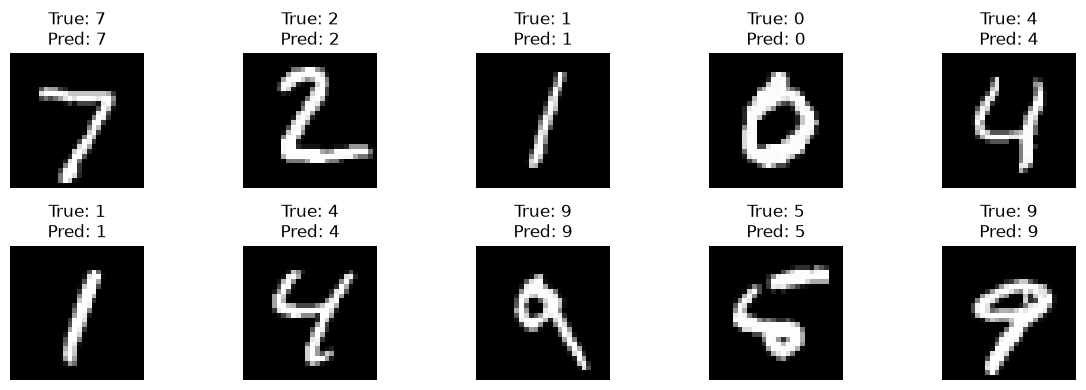

In [10]:
y_pred = cnn.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'True: {y_test[i]}\nPred: {y_pred_classes[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()